## Module structure:

```text
gravitatis-assist/
│
├── assisted_probe/
│   ├── __init__.py
│   ├── assisted_probe.py
│   ├── config.ini
│   └── outputfolder/
│
├── pyproject.toml
├── README.md
├── tests/
│   └── test_mission_titan.py
│
└── analysis/
    └── mission_titan.ipynb
```

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# Set plots style
plt.style.use(['science', 'notebook', 'no-latex'])

# Import our module
from assisted_probe import GravityAssistance, RunAssistance, AnimateAssistance

## Gravity assist comparison (3 points)
### (i) Use your module/script to run and show three simulations for gravity assists around different celestial bodies. It may be helpful to compare the probe trajectories in a single plot.

| Body | Mass ($M$) | Integration Method |
|-----|-----|-----|
| Mars | $3.2\times10^{-7}\,M_\odot$ | RK4 |
| Jupiter | $9.5\times10^{-4}\,M_\odot$ | RK4 |
| Saturn | $2.9\times10^{-4}\,M_\odot$ | RK4 |

In [2]:
## Mars
sim1 = GravityAssistance("./config_mars.ini")
t1, S1 = RunAssistance(sim1).integrator()
## Jupiter
sim2 = GravityAssistance("./config_jupiter.ini")
t2, S2 = RunAssistance(sim2).integrator()
## Saturn
sim3 = GravityAssistance("./config_saturn.ini")
t3, S3 = RunAssistance(sim3).integrator()

# Safe check
# print(type(t1), type(S1))

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.



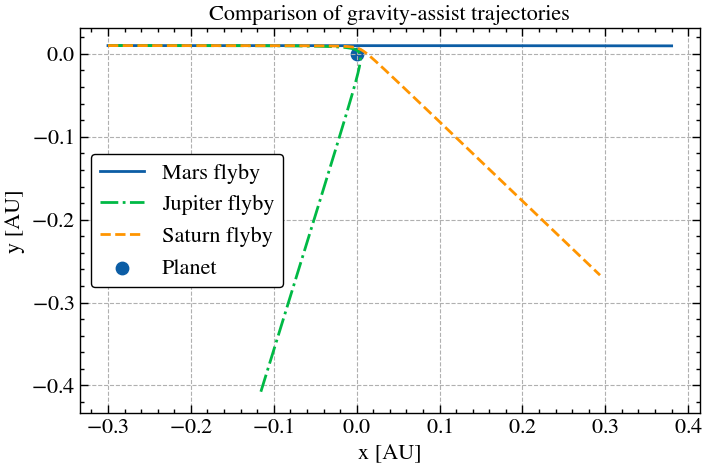

In [3]:
# Plotting
plt.figure(figsize=(8, 5))

plt.plot(S1[:, 0], S1[:, 1], label="Mars flyby")
plt.plot(S2[:, 0], S2[:, 1], linestyle = '-.', label="Jupiter flyby")
plt.plot(S3[:, 0], S3[:, 1], linestyle = '--', label="Saturn flyby")

# Planet location
plt.scatter(0, 0, marker="o", s=80, label="Planet")

plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Comparison of gravity-assist trajectories")
#plt.axis("equal")
plt.grid(True, linestyle="--", linewidth=0.8)
plt.legend(frameon=True, facecolor="white", edgecolor="black", framealpha=1)
plt.show()

### (j) Using the velocity history of the probe, estimate the **change in velocity obtained during the flyby** and estimate the **time required to reach the orbital distance of Saturn**. Which body provides the **most efficient gravity assist**?

In [4]:
def flyby_v(state):
    '''
    Estimates the velocity change (gravity assist effect) from a flyby.
    
    This function compares the initial and final velocity vectors of the probe
    to estimate the effective change in velocity produced by the gravitational
    interaction with the planet.

    Inputs
    ----------
    state : ndarray, shape (N, 4)
        State array [x, y, vx, vy] over time.

    Returns
    -------
    speed_i : float
        Initial speed of the probe before the flyby (AU/yr).
    speed_f : float
        Final speed of the probe after the flyby (AU/yr).
    delta_v_mag : float
        Magnitude of the change in velocity vector |v_f - v_i| (AU/yr).

    '''
    # Extract velocity components from the state array
    vx = state[:, 2]
    vy = state[:, 3]
    
    # Initial velocity vector (before flyby)
    v_i = np.array([vx[0], vy[0]])
    
    # Final velocity vector (after flyby)
    v_f = np.array([vx[-1], vy[-1]])
    
    # Change in velocity vector due to the flyby
    delta_vec = v_f - v_i
    
    # Magnitude of the velocity change (gravity assist strength)
    delta_v_mag = np.linalg.norm(delta_vec)

    # Initial and final speeds (magnitudes of velocity)
    speed_i = np.linalg.norm(v_i)
    speed_f = np.linalg.norm(v_f)

    return speed_i, speed_f, delta_v_mag

# Call our function for each case
speed_i_m, speed_f_m, dv_m = flyby_v(S1)
speed_i_j, speed_f_j, dv_j = flyby_v(S2)
speed_i_s, speed_f_s, dv_s = flyby_v(S3)

print("Mars:")
print(f"  Initial speed : {speed_i_m:.4f} AU/yr")
print(f"  Final speed   : {speed_f_m:.4f} AU/yr")
print(f"  Delta v       : {dv_m:.4f} AU/yr\n")

print("Jupiter:")
print(f"  Initial speed : {speed_i_j:.4f} AU/yr")
print(f"  Final speed   : {speed_f_j:.4f} AU/yr")
print(f"  Delta v       : {dv_j:.4f} AU/yr\n")

print("Saturn:")
print(f"  Initial speed : {speed_i_s:.4f} AU/yr")
print(f"  Final speed   : {speed_f_s:.4f} AU/yr")
print(f"  Delta v       : {dv_s:.4f} AU/yr")

Mars:
  Initial speed : 1.7000 AU/yr
  Final speed   : 1.7000 AU/yr
  Delta v       : 0.0015 AU/yr

Jupiter:
  Initial speed : 1.7000 AU/yr
  Final speed   : 1.6775 AU/yr
  Delta v       : 2.7186 AU/yr

Saturn:
  Initial speed : 1.7000 AU/yr
  Final speed   : 1.6945 AU/yr
  Delta v       : 1.2641 AU/yr


In [5]:
# Orbital radii in AU
a_mars = 1.52
a_jupiter = 5.20
a_saturn = 9.54

# Get the time using v=r/t
time_mars_to_saturn = (a_saturn - a_mars) / speed_f_m
time_jupiter_to_saturn = (a_saturn - a_jupiter) / speed_f_j
time_saturn_to_saturn = 0.0

print("Estimated time to Saturn orbit:")
print(f"Mars assist   : {time_mars_to_saturn:.3f} yr")
print(f"Jupiter assist: {time_jupiter_to_saturn:.3f} yr")
print(f"Saturn assist : {time_saturn_to_saturn:.3f} yr")

Estimated time to Saturn orbit:
Mars assist   : 4.718 yr
Jupiter assist: 2.587 yr
Saturn assist : 0.000 yr


The velocity change was computed by comparing the initial and final velocity vectors of the probe for each flyby. Jupiter produces the largest velocity change, followed by Saturn and then Mars, indicating that Jupiter provides the most efficient gravity assist due to its larger mass and stronger gravitational field. Jupiter also makes the probe take the shortest time to reach the orbital distance of Saturn. 

Thus, Jupyter provides the more efficient gravity assistance.

## Effect of flyby proximity (3 points)

Assume the central body corresponds to **Jupiter**.

| Case | Impact parameter ($b$) | Integration Method |
|-----|-----|-----|
| Distant flyby | $0.020\,\rm AU$ | RK2 |
| Standard flyby | $0.010\,\rm AU$ | RK2 |
| Close flyby | $0.005\,\rm AU$ | RK2 |

### (k) Use your module/script to run and show these three simulations. It may be helpful to compare the trajectories in a single plot.

In [6]:
## Distant flyby
sim4 = GravityAssistance("./config_jupiter_dfly.ini")
_, S4 = RunAssistance(sim4).integrator()
## Standard flyby
sim5 = GravityAssistance("./config_jupiter_sfly.ini")
_, S5 = RunAssistance(sim5).integrator()
## Standard flyby
sim6 = GravityAssistance("./config_jupiter_cfly.ini")
_, S6 = RunAssistance(sim6).integrator()

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.



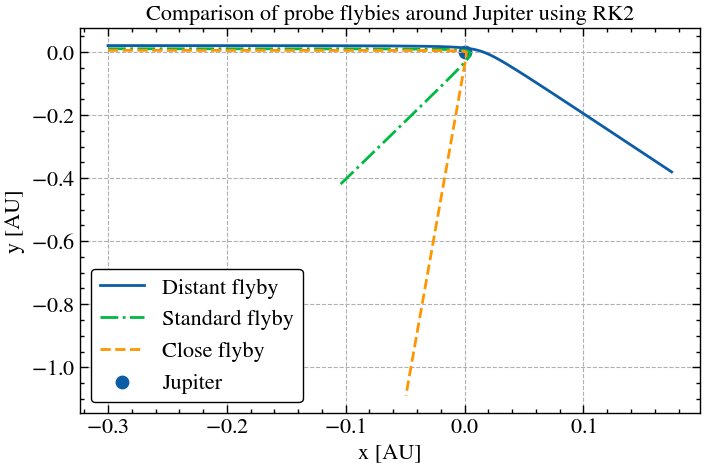

In [7]:
# Plotting
plt.figure(figsize=(8, 5))

plt.plot(S4[:, 0], S4[:, 1], label="Distant flyby")
plt.plot(S5[:, 0], S5[:, 1], linestyle = '-.', label="Standard flyby")
plt.plot(S6[:, 0], S6[:, 1], linestyle = '--', label="Close flyby")

# Planet location
plt.scatter(0, 0, marker="o", s=80, label="Jupiter")

plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Comparison of probe flybies around Jupiter using RK2")
#plt.ylim(-0.2, 0.05)
plt.grid(True, linestyle="--", linewidth=0.8)
plt.legend(frameon=True, facecolor="white", edgecolor="black", framealpha=1)
plt.show()

### (l) Describe how the trajectories change as the flyby distance decreases. Which case produces the strongest gravity assist?

We would expect that as the probe passes closer to Jupiter the gravitational interaction becomes so strong that the probe seems to get back on its trajectory. 

However, we have that the case of  *close flyby* presents a smaller deflection of the trajectory than the *standard flyby*. This is due to the second-order accuracy error of the RK2 method, which may be underestimating the deflection because of numerical error.
So, for this method the case of **close flyby** seems to produce the strongest gravity assist.
A more physically meaningful comparison may be done using the RK4 method for all flybies.

## Numerical convergence (3 points)
### (m) Use your script to generate additional simulations with the same initial conditions using **RK2**, **RK4**, and the **higher-order SciPy integrator**. Compare the probe trajectories for all methods in a single plot.


In [8]:
## Distant flyby
sim7 = GravityAssistance("./config_jupiter.ini")
_, S7 = RunAssistance(sim7).integrator()
## Standard flyby
sim8 = GravityAssistance("./config_jupiter_sfly.ini")
_, S8 = RunAssistance(sim8).integrator()
## Standard flyby
sim9 = GravityAssistance("./config_jupiter_scipy.ini")
_, S9 = RunAssistance(sim9).integrator()

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.



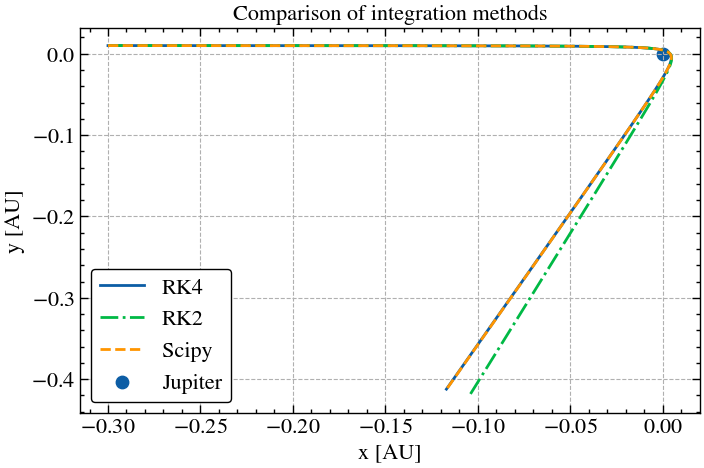

In [9]:
# Plotting
plt.figure(figsize=(8, 5))

plt.plot(S7[:, 0], S7[:, 1], label="RK4")
plt.plot(S8[:, 0], S8[:, 1], linestyle = '-.', label="RK2")
plt.plot(S9[:, 0], S9[:, 1], linestyle = '--', label="Scipy")

# Planet location
plt.scatter(0, 0, marker="o", s=80, label="Jupiter")

plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Comparison of integration methods")
#plt.ylim(-0.2, 0.05)
plt.grid(True, linestyle="--", linewidth=0.8)
plt.legend(frameon=True, facecolor="white", edgecolor="black", framealpha=1)
plt.show()

### (n) Measure convergence of the simulations with RK2 and RK4 by integrating at a number of different time steps (**go in decreasing size of h**). To analyse convergence, define a measure for the error (**choose an appropiate norm**) with respect to the higher-order method and plot it against different time steps for both methods.
- Show in log scale.

In [10]:
def run_sim(config_file, method, steps):
    '''
    Run one simulation with a chosen method and number of steps.
    
    Inputs
    ----------
    config_file : str
        Path to the .ini file.
    method : str
        Numerical integration method.
    steps : int
        Number of time steps used to discretize the simulation time.

    Returns
    -------
    time : ndarray
        Array of time values.
    state : ndarray
        State array with columns [x, y, vx, vy] at each time step.
    '''
    # Create a simulation object using parameters from the config file
    sim = GravityAssistance(config_file)
    # Override parameters
    sim.method = method
    sim.steps = steps
    # Integrate the simulation object
    time, state = RunAssistance(sim).integrator()
    
    return time, state


def error_norm(state_num, state_ref, norm="l2"):
    '''
    Compute the error between a numerical solution and the scipy solution.

    Inputs
    ----------
    state_num : ndarray, shape (N, 4)
        Numerical state array [x, y, vx, vy] from RK2 or RK4.
    state_ref : ndarray, shape (N, 4)
        Reference state array evaluated on the same time grid.
    norm : str
        Norm used to measure the error:
        - "l2"  : Euclidean norm (default)
        - "l1"  : Manhattan norm
        - "inf" : Infinity norm (maximum absolute error)

    Returns
    -------
    error : float
        Error between numerical and reference solution at final time.
    '''
    # Final position difference
    diff = state_num[-1, :2] - state_ref[-1, :2]

    if norm == "l2":
        return np.linalg.norm(diff, 2)
    elif norm == "l1":
        return np.linalg.norm(diff, 1)
    elif norm == "inf":
        return np.linalg.norm(diff, np.inf)
    else:
        raise ValueError("Norm must be 'l1', 'l2', or 'inf'")

# Define config file path
config_file = "./config_jupiter.ini"
# Define steps list
steps_list = [250, 500, 1000, 2000, 4000, 8000]

# Empty lists
h_values = []
errors_rk2 = []
errors_rk4 = []

# Get the total simulation file
sim_tmp = GravityAssistance(config_file)
N = sim_tmp.N

# For loop over the steps list
for steps in steps_list:
    # The time step size is h = N / steps, where N is the total simulation time.
    h = N / steps
    # Append step size values to empty list
    h_values.append(h)

    # Reference solution
    t_ref, state_ref = run_sim(config_file, method="scipy", steps=steps)

    # RK2 solution on that grid
    t_rk2, state_rk2 = run_sim(config_file, method="rk2", steps=steps)
    # Compute error
    err_rk2 = error_norm(state_rk2, state_ref)
    # Append errors
    errors_rk2.append(err_rk2)

    # RK4 solution on that grid
    t_rk4, state_rk4 = run_sim(config_file, method="rk4", steps=steps)
    # Compute error
    err_rk4 = error_norm(state_rk4, state_ref)
    # Append errors
    errors_rk4.append(err_rk4)

# Convert list to arrays
h_values = np.array(h_values)
errors_rk2 = np.array(errors_rk2)
errors_rk4 = np.array(errors_rk4)

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved successfully.

 ==> Integration finished and file saved success

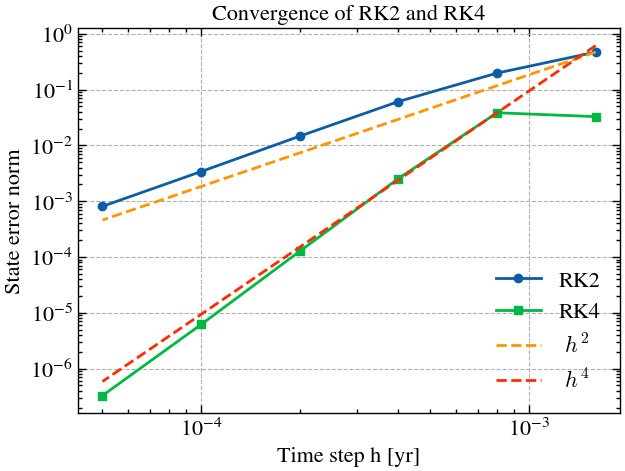

In [11]:
# Plotting
plt.figure(figsize=(7, 5))

plt.loglog(h_values, errors_rk2, 'o-', label="RK2")
plt.loglog(h_values, errors_rk4, 's-', label="RK4")

# Theoretical slopes(error = C*h^p, we're estimating C for one element)
plt.loglog(h_values, errors_rk2[0]*(h_values/h_values[0])**2, '--', label=r'$~ h^2$')
plt.loglog(h_values, errors_rk4[1]*(h_values/h_values[1])**4, '--', label=r'$~ h^4$')

plt.xlabel("Time step h [yr]")
plt.ylabel("State error norm")
plt.title("Convergence of RK2 and RK4")
plt.grid(True, linestyle="--", linewidth=0.8)
plt.legend()
plt.show()

- RK2 shows second-order convergence.
- RK4 shows fourth-order convergence. However, for large $h$ the error is almost constant, the method is outside its asymptotic convergence regime, i.e the Taylor expansion assumption breaks. For sufficiently small time steps, the expected convergence behavior is recovered.